In [1]:
import os
os.environ["JAVA_HOME"] = "/usr/lib/jvm/java-11-openjdk-amd64"
os.environ["PATH"] = os.environ["JAVA_HOME"] + "/bin:" + os.environ["PATH"]

from pyspark.sql import SparkSession
from pyspark.sql import functions as F
from pyspark.sql.types import (
    StructType, StructField,
    IntegerType, StringType, FloatType
)

from pyspark.ml import Pipeline
from pyspark.ml.feature import (
    StringIndexer,
    OneHotEncoder,
    VectorAssembler,
    StandardScaler,
)
from pyspark.ml.regression import (
    LinearRegression,
    RandomForestRegressor,
    GBTRegressor,
)
from pyspark.ml.evaluation import RegressionEvaluator

import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

plt.style.use("ggplot")
sns.set(font_scale=1.1)

In [2]:
spark = (
    SparkSession.builder
    .appName("Demographics EDA + Classification (Kaggle + PySpark)")
    .master("local[*]")   # Spark тут все одно працює на CPU, навіть якщо в Kaggle є GPU
    .getOrCreate()
)

print("Spark version:", spark.version)

Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
25/12/01 09:51:22 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


Spark version: 3.5.1


In [3]:
FILE_PATH_DEMO = "/kaggle/input/demographisc/psam_pusa.csv"  

df_demo = (
    spark.read
    .option("header", "true")
    .option("inferSchema", "true")   
    .csv(FILE_PATH_DEMO)
)

print("\n=== Demographics dataframe loaded ===")
print("Rows:", df_demo.count(), "Columns:", len(df_demo.columns))
df_demo.printSchema()
df_demo.show(5, truncate=False)


=== Demographics dataframe loaded ===


Rows: 1724154 Columns: 287
root
 |-- RT: string (nullable = true)
 |-- SERIALNO: string (nullable = true)
 |-- DIVISION: integer (nullable = true)
 |-- SPORDER: integer (nullable = true)
 |-- PUMA: integer (nullable = true)
 |-- REGION: integer (nullable = true)
 |-- ST: integer (nullable = true)
 |-- ADJINC: integer (nullable = true)
 |-- PWGTP: integer (nullable = true)
 |-- AGEP: integer (nullable = true)
 |-- CIT: integer (nullable = true)
 |-- CITWP: integer (nullable = true)
 |-- COW: integer (nullable = true)
 |-- DDRS: integer (nullable = true)
 |-- DEAR: integer (nullable = true)
 |-- DEYE: integer (nullable = true)
 |-- DOUT: integer (nullable = true)
 |-- DPHY: integer (nullable = true)
 |-- DRAT: integer (nullable = true)
 |-- DRATX: integer (nullable = true)
 |-- DREM: integer (nullable = true)
 |-- ENG: integer (nullable = true)
 |-- FER: integer (nullable = true)
 |-- GCL: integer (nullable = true)
 |-- GCM: integer (nullable = true)
 |-- GCR: integer (nullable = true)
 

25/12/01 09:52:20 WARN SparkStringUtils: Truncated the string representation of a plan since it was too large. This behavior can be adjusted by setting 'spark.sql.debug.maxToStringFields'.


+---+-------------+--------+-------+----+------+---+-------+-----+----+---+-----+----+----+----+----+----+----+----+-----+----+----+----+---+----+----+------+-----+-----+-----+-----+-----+-----+-----+----+-----+-----+------+----+---+-----+-----+-----+-----+------+---+---+----+----+-----+----+-----+----+-----+----+----+----+----+----+----+---+---+--------+----+---+----+----+----+---+----+-----+-----+----+---+----+----+----+---+-----+-----+------+---+-------+----+---+-----+-----+-----+----+----+----+----+----+-------+-----+---+------+--------+----+----+----+----+-----+-----+----+------+-------+-----+-------+------+------+-----+-----+-----+-------+------+------+-----+------+-----+------+------+----+-------+---------+----+----+------+----+----+-----+-----+-----+------+-----+------+------+------+-----+------+------+------+-------+------+-----+-----+-----+-----+-----+-----+-----+-------+--------+-------+-------+-------+-------+-------+-------+-------+-------+-------+-------+-----+-----+-----

In [4]:
n_rows = df_demo.count()

print("\n=== Missing values per column (count) ===")
null_counts = df_demo.select([
    F.sum(F.col(c).isNull().cast("int")).alias(c) for c in df_demo.columns
])
null_counts.show(truncate=False)

print("\n=== Missing values per column (share) ===")
null_share = df_demo.select([
    (F.sum(F.col(c).isNull().cast("int")) / n_rows).alias(c) for c in df_demo.columns
])
null_share.show(truncate=False)


=== Missing values per column (count) ===


+---+--------+--------+-------+----+------+---+------+-----+----+---+-------+------+-----+----+----+------+-----+-------+-------+-----+-------+-------+------+-------+-------+------+-----+-----+-----+-----+-----+-----+-----+------+-------+-------+------+-----+---+------+------+------+------+------+-----+------+-------+-------+-------+-------+-------+-------+-------+-------+------+------+------+------+------+------+------+--------+------+-----+-------+-----+------+---+------+------+------+------+------+------+------+-------+---+-----+-----+-------+---+-------+-------+------+-------+-------+-----+----+------+-------+-------+-------+-------+-------+------+------+--------+-------+-----+------+-------+------+------+----+------+-------+------+-------+------+------+-----+-----+-----+-------+------+------+-----+------+-----+------+------+-----+-------+---------+-------+-------+------+-------+----+-----+-----+-----+------+-----+------+------+------+-----+------+------+------+-------+------+-----

+---+--------+--------+-------+----+------+---+------+-----+----+---+------------------+------------------+--------------------+----+----+-------------------+--------------------+------------------+------------------+--------------------+------------------+------------------+-------------------+------------------+------------------+------+-----+-----+-----+-----+-----+-----+-----+-------------------+------------------+------------------+------------------+--------------------+---+------------------+------------------+------------------+------------------+------------------+--------------------+-----------------+----------------+----------------+----------------+----------------+----------------+----------------+----------------+----------------+------------------+------------------+------------------+------------------+------------------+-------------------+-------------------+--------+-------------------+--------------------+------------------+--------------------+-------------------+

In [5]:
numeric_cols = [
    c for c, t in df_demo.dtypes
    if t in ["int", "bigint", "double", "float", "long"]
]

print("\n=== Numeric columns (first 30) ===")
print(numeric_cols[:30])

if numeric_cols:
    df_demo.select(numeric_cols).describe().show(truncate=False)


=== Numeric columns (first 30) ===
['DIVISION', 'SPORDER', 'PUMA', 'REGION', 'ST', 'ADJINC', 'PWGTP', 'AGEP', 'CIT', 'CITWP', 'COW', 'DDRS', 'DEAR', 'DEYE', 'DOUT', 'DPHY', 'DRAT', 'DRATX', 'DREM', 'ENG', 'FER', 'GCL', 'GCM', 'GCR', 'HIMRKS', 'HINS1', 'HINS2', 'HINS3', 'HINS4', 'HINS5']


25/12/01 09:53:55 WARN DAGScheduler: Broadcasting large task binary with size 1046.4 KiB
25/12/01 09:57:45 WARN DAGScheduler: Broadcasting large task binary with size 2.8 MiB


+-------+------------------+------------------+------------------+------------------+------------------+---------------------+-----------------+-----------------+------------------+------------------+------------------+------------------+-------------------+-------------------+------------------+-------------------+------------------+-------------------+------------------+------------------+-------------------+-------------------+------------------+------------------+------------------+------------------+-------------------+-------------------+------------------+-------------------+-------------------+-------------------+------------------+------------------+------------------+------------------+------------------+------------------+-------------------+-------------------+------------------+-------------------+------------------+------------------+------------------+-------------------+------------------+-------------------+-------------------+-------------------+--------------------+-

In [6]:
key_cols = [c for c in [
    "AGEP",      # age
    "SEX",       # sex
    "SCHL",      # education level
    "WAGP",      # wage
    "HICOV",     # health insurance coverage
    "HISP",      # hispanic origin
    "RAC1P",     # race
    "ESR",       # employment status
    "MSP"        # marital status
] if c in df_demo.columns]

print("\n=== Key columns present ===")
print(key_cols)
df_demo.select(key_cols).show(10, truncate=False)


=== Key columns present ===
['AGEP', 'SEX', 'SCHL', 'WAGP', 'HICOV', 'HISP', 'RAC1P', 'ESR', 'MSP']
+----+---+----+-----+-----+----+-----+---+---+
|AGEP|SEX|SCHL|WAGP |HICOV|HISP|RAC1P|ESR|MSP|
+----+---+----+-----+-----+----+-----+---+---+
|85  |2  |19  |0    |1    |1   |9    |6  |3  |
|51  |1  |17  |12500|1    |1   |1    |6  |3  |
|36  |2  |11  |16400|1    |1   |2    |6  |6  |
|74  |1  |1   |0    |1    |1   |2    |6  |6  |
|49  |1  |19  |0    |2    |1   |1    |6  |4  |
|31  |1  |17  |300  |2    |1   |2    |6  |6  |
|76  |2  |19  |0    |1    |1   |2    |6  |3  |
|60  |1  |13  |15600|2    |1   |2    |6  |2  |
|35  |1  |14  |27600|2    |1   |2    |6  |6  |
|72  |2  |16  |0    |1    |1   |2    |6  |3  |
+----+---+----+-----+-----+----+-----+---+---+
only showing top 10 rows



In [7]:
SAMPLE_FRAC = 0.01 

df_for_pd = (
    df_demo
    .sample(withReplacement=False, fraction=SAMPLE_FRAC, seed=42)
    .select([c for c in df_demo.columns if c in key_cols or c in numeric_cols])
    .dropna(subset=[c for c in ["AGEP", "WAGP"] if c in df_demo.columns])
)

pdf = df_for_pd.toPandas()
print("\n=== Pandas sample head ===")
print(pdf.head())
print("Sample shape:", pdf.shape)


=== Pandas sample head ===
   DIVISION  SPORDER  PUMA  REGION  ST   ADJINC  PWGTP  AGEP  CIT  CITWP  ...  \
0         6        1  2500       3   1  1042311     65    19    1    NaN  ...   
1         6        1  1403       3   1  1042311    120    18    1    NaN  ...   
2         6        1  2000       3   1  1042311     64    20    1    NaN  ...   
3         6        1   402       3   1  1042311     37    20    1    NaN  ...   
4         6        1  2803       3   1  1042311     12    56    1    NaN  ...   

   PWGTP71  PWGTP72  PWGTP73  PWGTP74  PWGTP75  PWGTP76  PWGTP77  PWGTP78  \
0        0       55       62        1       66      104        1        1   
1        1      103      133      263        1      208      202       96   
2       67       73        0        0      134      116        1       64   
3       87        0        0       31       32       39       32       33   
4       12       13       13       15       13       13       13       14   

   PWGTP79  PWGTP80  


/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1458: RuntimeWarning: invalid value encountered in greater
  has_large_values = (abs_vals > 1e6).any()
/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1459: RuntimeWarning: invalid value encountered in less
  has_small_values = ((abs_vals < 10 ** (-self.digits)) & (abs_vals > 0)).any()
/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1459: RuntimeWarning: invalid value encountered in greater
  has_small_values = ((abs_vals < 10 ** (-self.digits)) & (abs_vals > 0)).any()


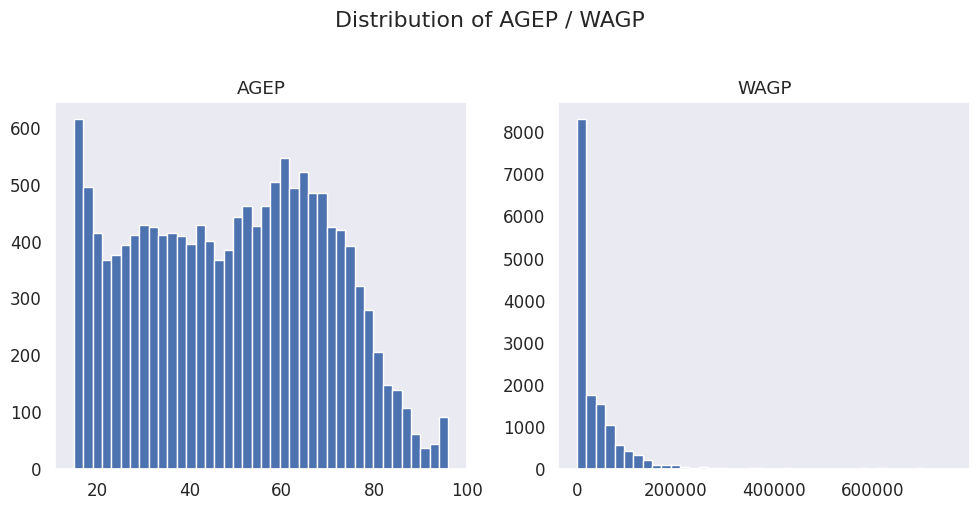

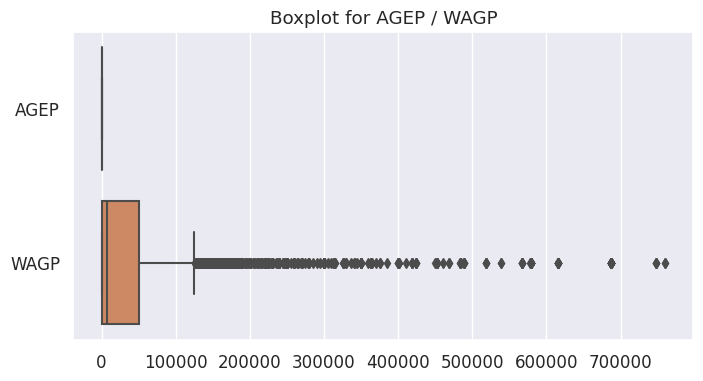


=== Value counts for SEX ===
     count
SEX       
2     7507
1     7135

=== Value counts for HICOV ===
       count
HICOV       
1      13588
2       1054

=== Value counts for HISP ===
      count
HISP       
1     12213
2      1395
3       205
4       153
24      138
11       98
7        83
16       57
5        45
21       44
23       42
8        37
19       28
9        28
17       22
10       14
15       13
13       12
6         5
14        4
20        3
12        2
18        1

=== Value counts for ESR ===
     count
ESR       
1.0   7831
6.0   6069
3.0    338
NaN    170
2.0    155
4.0     79


/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1458: RuntimeWarning: invalid value encountered in greater
  has_large_values = (abs_vals > 1e6).any()
/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1459: RuntimeWarning: invalid value encountered in less
  has_small_values = ((abs_vals < 10 ** (-self.digits)) & (abs_vals > 0)).any()
/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1459: RuntimeWarning: invalid value encountered in greater
  has_small_values = ((abs_vals < 10 ** (-self.digits)) & (abs_vals > 0)).any()


In [8]:
plot_num_cols = [c for c in ["AGEP", "WAGP"] if c in pdf.columns]

if plot_num_cols:
    _ = pdf[plot_num_cols].hist(
        bins=40,
        figsize=(10, 5),
        grid=False
    )
    plt.suptitle("Distribution of AGEP / WAGP", y=1.02)
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(8, 4))
    sns.boxplot(data=pdf[plot_num_cols], orient="h")
    plt.title("Boxplot for AGEP / WAGP")
    plt.show()

# Categorical value counts
for col in ["SEX", "HICOV", "HISP", "ESR"]:
    if col in pdf.columns:
        print(f"\n=== Value counts for {col} ===")
        print(
            pdf[col]
            .value_counts(dropna=False)
            .rename("count")
            .to_frame()
        )

/usr/local/lib/python3.11/dist-packages/matplotlib/colors.py:721: RuntimeWarning: invalid value encountered in less
  xa[xa < 0] = -1


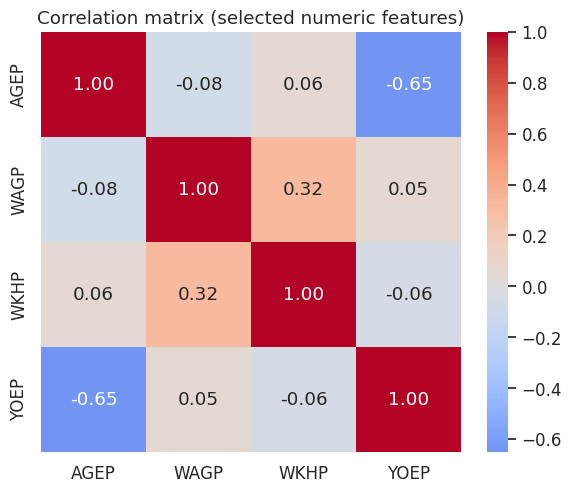

In [9]:
corr_cols = [c for c in ["AGEP", "WAGP", "WKHP", "YOEP"] if c in pdf.columns]

if corr_cols:
    corr = pdf[corr_cols].corr(numeric_only=True)

    plt.figure(figsize=(6, 5))
    sns.heatmap(
        corr,
        cmap="coolwarm",
        center=0,
        square=True,
        cbar=True,
        annot=True,
        fmt=".2f",
        xticklabels=corr.columns,   # назви змінних
        yticklabels=corr.columns
    )
    plt.title("Correlation matrix (selected numeric features)")
    plt.tight_layout()
    plt.show()


In [10]:
if "HICOV" not in df_demo.columns:
    raise Exception("Column 'HICOV' not found in dataset. Перевір назву колонки в CSV.")

df = df_demo.filter(F.col("HICOV").isNotNull())

# Перетворюємо HICOV у label: 1 якщо HICOV == 1, інакше 0
df = df.withColumn(
    "label",
    (F.col("HICOV") == 1).cast("int")
)

print("\n=== Label distribution (0 / 1) ===")
df.groupBy("label").count().orderBy("label").show()


=== Label distribution (0 / 1) ===


+-----+-------+
|label|  count|
+-----+-------+
|    0| 115949|
|    1|1608205|
+-----+-------+



In [11]:
numeric_features = []
for col in ["AGEP", "WAGP", "WKHP"]:
    if col in df.columns:
        numeric_features.append(col)

categorical_features = []
for col in ["SEX", "SCHL", "HISP", "ESR", "MSP", "RAC1P"]:
    if col in df.columns:
        categorical_features.append(col)

print("\n=== Numeric features used ===")
print(numeric_features)
print("=== Categorical features used ===")
print(categorical_features)

# dropna ТІЛЬКИ по числових фічах + label
required_cols = numeric_features + ["label"]
df_model = df.dropna(subset=required_cols)

if "WAGP" in df_model.columns:
    df_model = df_model.filter(F.col("WAGP") >= 0)

print("\nRows for modeling:", df_model.count())
df_model.select(numeric_features + categorical_features + ["label"]).show(5, truncate=False)


=== Numeric features used ===
['AGEP', 'WAGP', 'WKHP']
=== Categorical features used ===
['SEX', 'SCHL', 'HISP', 'ESR', 'MSP', 'RAC1P']



Rows for modeling: 882399
+----+-----+----+---+----+----+---+---+-----+-----+
|AGEP|WAGP |WKHP|SEX|SCHL|HISP|ESR|MSP|RAC1P|label|
+----+-----+----+---+----+----+---+---+-----+-----+
|51  |12500|52  |1  |17  |1   |6  |3  |1    |1    |
|36  |16400|35  |2  |11  |1   |6  |6  |2    |1    |
|49  |0    |20  |1  |19  |1   |6  |4  |1    |0    |
|31  |300  |30  |1  |17  |1   |6  |6  |2    |0    |
|60  |15600|52  |1  |13  |1   |6  |2  |2    |0    |
+----+-----+----+---+----+----+---+---+-----+-----+
only showing top 5 rows



In [12]:

train_df, test_df = df_model.randomSplit([0.8, 0.2], seed=42)
print("Train size:", train_df.count())
print("Test size: ", test_df.count())


label_stats = train_df.groupBy("label").count().collect()
total_count = sum(row["count"] for row in label_stats)
num_classes = len(label_stats)

class_weights = {
    int(row["label"]): float(total_count) / (num_classes * float(row["count"]))
    for row in label_stats
}

print("\n=== Class weights ===")
for lbl, w in class_weights.items():
    print(f"label={lbl}: weight={w:.4f}")

# будуємо map(label -> weight) для використання у withColumn
weight_mapping_expr = F.create_map(
    *[x for kv in class_weights.items() for x in (F.lit(kv[0]), F.lit(kv[1]))]
)

# додаємо стовпчик class_weight у train і test
train_df = train_df.withColumn("class_weight", weight_mapping_expr[F.col("label")])
test_df  = test_df.withColumn("class_weight",  weight_mapping_expr[F.col("label")])

print("\nTrain with weights sample:")
train_df.select("label", "class_weight").groupBy("label").agg(
    F.count("*").alias("n"),
    F.avg("class_weight").alias("avg_weight")
).show()


Train size: 706148


Test size:  176251



=== Class weights ===
label=1: weight=0.5419
label=0: weight=6.4719

Train with weights sample:


+-----+------+------------------+
|label|     n|        avg_weight|
+-----+------+------------------+
|    1|651593|0.5418627885810666|
|    0| 54555| 6.471890752451291|
+-----+------+------------------+



Columns for numeric correlation: ['AGEP', 'WAGP', 'WKHP', 'label']


   AGEP   WAGP  WKHP  label
0    51  12500    52      1
1    36  16400    35      1
2    49      0    20      0
3    31    300    30      0
4    60  15600    52      0


/usr/local/lib/python3.11/dist-packages/matplotlib/colors.py:721: RuntimeWarning: invalid value encountered in less
  xa[xa < 0] = -1


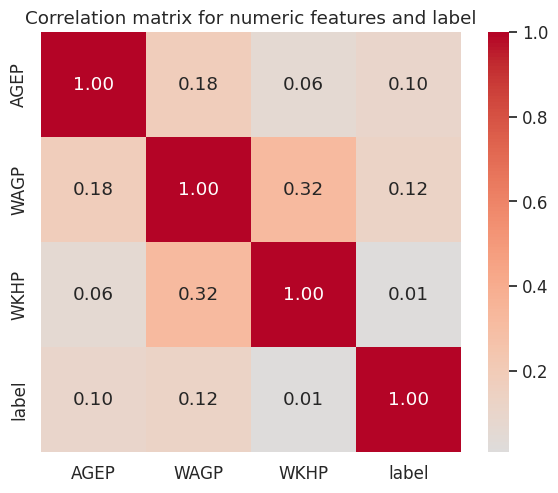

In [21]:
corr_cols = numeric_features + ["label"]
print("Columns for numeric correlation:", corr_cols)

SAMPLE_FOR_CORR = 50000

df_corr_pd = (
    df_model
    .select(corr_cols)
    .limit(SAMPLE_FOR_CORR)
    .toPandas()
)

print(df_corr_pd.head())

corr = df_corr_pd.corr(numeric_only=True)

plt.figure(figsize=(6, 5))
sns.heatmap(
    corr,
    cmap="coolwarm",
    center=0,
    square=True,
    cbar=True,
    annot=True,
    fmt=".2f",
    xticklabels=corr.columns,
    yticklabels=corr.columns
)
plt.title("Correlation matrix for numeric features and label")
plt.tight_layout()
plt.show()

In [13]:
indexers = [
    StringIndexer(
        inputCol=c,
        outputCol=f"{c}_idx",
        handleInvalid="keep"
    )
    for c in categorical_features
]

encoder = OneHotEncoder(
    inputCols=[f"{c}_idx" for c in categorical_features],
    outputCols=[f"{c}_ohe" for c in categorical_features]
)

num_vec_assembler = VectorAssembler(
    inputCols=numeric_features,
    outputCol="num_vec"
)

scaler = StandardScaler(
    inputCol="num_vec",
    outputCol="num_scaled",
    withMean=True,
    withStd=True
)

final_assembler = VectorAssembler(
    inputCols=["num_scaled"] + [f"{c}_ohe" for c in categorical_features],
    outputCol="features"
)

base_stages = indexers + [encoder, num_vec_assembler, scaler, final_assembler]

In [14]:
from pyspark.ml.classification import (
    LogisticRegression,
    DecisionTreeClassifier,
    RandomForestClassifier,
)

from pyspark.ml.evaluation  import (
    BinaryClassificationEvaluator,
    MulticlassClassificationEvaluator,
)



lr = LogisticRegression(
    featuresCol="features",
    labelCol="label",
    maxIter=50,
    weightCol="class_weight"   
)

dt = DecisionTreeClassifier(
    featuresCol="features",
    labelCol="label",
    maxDepth=10,
    weightCol="class_weight"  
)

rf = RandomForestClassifier(
    featuresCol="features",
    labelCol="label",
    numTrees=50,
    maxDepth=10,
    subsamplingRate=0.8,
    weightCol="class_weight"   
)


models = [
    ("Logistic Regression", lr),
    ("Decision Tree", dt),
    ("Random Forest", rf),
]

bin_eval_roc = BinaryClassificationEvaluator(
    labelCol="label",
    rawPredictionCol="rawPrediction",
    metricName="areaUnderROC"
)

bin_eval_pr = BinaryClassificationEvaluator(
    labelCol="label",
    rawPredictionCol="rawPrediction",
    metricName="areaUnderPR"
)

acc_eval = MulticlassClassificationEvaluator(
    labelCol="label",
    predictionCol="prediction",
    metricName="accuracy"
)

f1_eval = MulticlassClassificationEvaluator(
    labelCol="label",
    predictionCol="prediction",
    metricName="f1"
)

In [15]:
def train_and_evaluate(name, estimator, train_df, test_df):
    print("=" * 70)
    print(f"Training model: {name}")
    
    pipeline = Pipeline(stages=base_stages + [estimator])
    model = pipeline.fit(train_df)
    
    preds = model.transform(test_df)
    preds.select("label", "prediction", "probability").show(10, truncate=False)
    
    auc_roc = bin_eval_roc.evaluate(preds)
    auc_pr  = bin_eval_pr.evaluate(preds)
    acc     = acc_eval.evaluate(preds)
    f1      = f1_eval.evaluate(preds)
    
    print(f"{name} – AUC ROC: {auc_roc:.4f}, AUC PR: {auc_pr:.4f}, Accuracy: {acc:.4f}, F1: {f1:.4f}")
    
    print("Confusion matrix (label, prediction):")
    (
        preds.groupBy("label", "prediction")
        .count()
        .orderBy("label", "prediction")
        .show()
    )
    
    return model, preds

In [16]:
results = {}
for name, est in models:
    model, preds = train_and_evaluate(name, est, train_df, test_df)
    results[name] = {"model": model, "predictions": preds}

print("\nAll three classifiers trained and evaluated.")

Training model: Logistic Regression


+-----+----------+----------------------------------------+
|label|prediction|probability                             |
+-----+----------+----------------------------------------+
|1    |0.0       |[0.7172103015448252,0.28278969845517477]|
|1    |0.0       |[0.727480090885874,0.27251990911412605] |
|1    |0.0       |[0.6024599794237162,0.3975400205762838] |
|1    |0.0       |[0.8974382081614315,0.1025617918385685] |
|0    |0.0       |[0.6073577943502859,0.3926422056497141] |
|1    |0.0       |[0.6285883453436962,0.37141165465630377]|
|1    |0.0       |[0.7973375401591247,0.20266245984087528]|
|0    |0.0       |[0.868358368648722,0.13164163135127804] |
|1    |0.0       |[0.5257958904513642,0.4742041095486358] |
|1    |0.0       |[0.835866785071094,0.16413321492890598] |
+-----+----------+----------------------------------------+
only showing top 10 rows



Logistic Regression – AUC ROC: 0.7643, AUC PR: 0.9725, Accuracy: 0.6829, F1: 0.7568
Confusion matrix (label, prediction):


+-----+----------+------+
|label|prediction| count|
+-----+----------+------+
|    0|       0.0|  9560|
|    0|       1.0|  3999|
|    1|       0.0| 51887|
|    1|       1.0|110805|
+-----+----------+------+

Training model: Decision Tree


25/12/01 10:16:24 WARN MemoryStore: Not enough space to cache rdd_635_4 in memory! (computed 8.5 MiB so far)
25/12/01 10:16:24 WARN BlockManager: Persisting block rdd_635_4 to disk instead.
25/12/01 10:16:33 WARN MemoryStore: Not enough space to cache rdd_635_8 in memory! (computed 5.6 MiB so far)
25/12/01 10:16:33 WARN BlockManager: Persisting block rdd_635_8 to disk instead.


...

25/12/01 10:28:30 WARN DAGScheduler: Broadcasting large task binary with size 2.9 MiB
25/12/01 10:29:12 WARN DAGScheduler: Broadcasting large task binary with size 2.9 MiB
25/12/01 10:29:54 WARN DAGScheduler: Broadcasting large task binary with size 2.9 MiB
25/12/01 10:30:35 WARN DAGScheduler: Broadcasting large task binary with size 2.9 MiB


Random Forest – AUC ROC: 0.7799, AUC PR: 0.9748, Accuracy: 0.6757, F1: 0.7514
Confusion matrix (label, prediction):


25/12/01 10:31:17 WARN DAGScheduler: Broadcasting large task binary with size 2.9 MiB


+-----+----------+------+
|label|prediction| count|
+-----+----------+------+
|    0|       0.0| 10166|
|    0|       1.0|  3393|
|    1|       0.0| 53771|
|    1|       1.0|108921|
+-----+----------+------+


All three classifiers trained and evaluated.


25/12/01 10:31:57 WARN DAGScheduler: Broadcasting large task binary with size 2.9 MiB


In [17]:
print("\n" + "=" * 70)
print("UNDER-SAMPLING EXPERIMENT (balanced train set, no class weights)")

label_stats_train = train_df.groupBy("label").count().collect()
stats_dict = {int(r["label"]): int(r["count"]) for r in label_stats_train}

print("\n=== Class distribution in original train_df ===")
for lbl, cnt in stats_dict.items():
    print(f"label={lbl}: count={cnt}")

if len(stats_dict) != 2:
    raise Exception("This undersampling block assumes exactly 2 classes in 'label'.")

majority_label = max(stats_dict, key=stats_dict.get)
minority_label = min(stats_dict, key=stats_dict.get)

majority_count = stats_dict[majority_label]
minority_count = stats_dict[minority_label]

print(f"\nMajority label: {majority_label} (count={majority_count})")
print(f"Minority label: {minority_label} (count={minority_count})")

minority_df = train_df.filter(F.col("label") == minority_label)
majority_df = train_df.filter(F.col("label") == majority_label)

fraction = float(minority_count) / float(majority_count)
print(f"\nSampling fraction for majority class: {fraction:.4f}")

majority_sampled_df = majority_df.sample(
    withReplacement=False,
    fraction=fraction,
    seed=42
)

under_train_df = minority_df.union(majority_sampled_df)

print("\n=== Class distribution in under-sampled train_df ===")
(
    under_train_df.groupBy("label")
    .count()
    .orderBy("label")
    .show()
)

print("Original train size:", train_df.count())
print("Under-sampled train size:", under_train_df.count())
print("Test size (unchanged):", test_df.count())

lr_under = LogisticRegression(
    featuresCol="features",
    labelCol="label",
    maxIter=50
)

dt_under = DecisionTreeClassifier(
    featuresCol="features",
    labelCol="label",
    maxDepth=10
)

rf_under = RandomForestClassifier(
    featuresCol="features",
    labelCol="label",
    numTrees=100,
    maxDepth=15
)

models_under = [
    ("Logistic Regression (undersampling)", lr_under),
    ("Decision Tree (undersampling)", dt_under),
    ("Random Forest (undersampling)", rf_under),
]

results_undersampling = {}

for name, est in models_under:
    model, preds = train_and_evaluate(name, est, under_train_df, test_df)
    results_undersampling[name] = {"model": model, "predictions": preds}

print("\nUndersampling experiment finished.")



UNDER-SAMPLING EXPERIMENT (balanced train set, no class weights)



=== Class distribution in original train_df ===
label=1: count=651593
label=0: count=54555

Majority label: 1 (count=651593)
Minority label: 0 (count=54555)

Sampling fraction for majority class: 0.0837

=== Class distribution in under-sampled train_df ===


+-----+-----+
|label|count|
+-----+-----+
|    0|54555|
|    1|54508|
+-----+-----+



Original train size: 706148


Under-sampled train size: 109063


...

+-----+----------+----------------------------------------+
|label|prediction|probability                             |
+-----+----------+----------------------------------------+
|1    |1.0       |[0.46934319114399264,0.5306568088560073]|
|1    |0.0       |[0.8059118745733009,0.19408812542669915]|
|1    |0.0       |[0.5681283311527572,0.43187166884724276]|
|1    |0.0       |[0.694631351517161,0.30536864848283884] |
|0    |0.0       |[0.7630102006696962,0.23698979933030395]|
|1    |1.0       |[0.4998012797306485,0.5001987202693515] |
|1    |0.0       |[0.7404957716225785,0.25950422837742143]|
|0    |0.0       |[0.8406173959243172,0.15938260407568278]|
|1    |1.0       |[0.40152194652555623,0.5984780534744438]|
|1    |0.0       |[0.5156934584041631,0.4843065415958368] |
+-----+----------+----------------------------------------+
only showing top 10 rows



25/12/01 11:23:44 WARN DAGScheduler: Broadcasting large task binary with size 18.5 MiB
25/12/01 11:24:47 WARN DAGScheduler: Broadcasting large task binary with size 18.5 MiB
25/12/01 11:25:53 WARN DAGScheduler: Broadcasting large task binary with size 18.5 MiB
25/12/01 11:26:54 WARN DAGScheduler: Broadcasting large task binary with size 18.5 MiB


Random Forest (undersampling) – AUC ROC: 0.7931, AUC PR: 0.9767, Accuracy: 0.6879, F1: 0.7606
Confusion matrix (label, prediction):


25/12/01 11:27:52 WARN DAGScheduler: Broadcasting large task binary with size 18.5 MiB
25/12/01 11:28:53 WARN DAGScheduler: Broadcasting large task binary with size 18.5 MiB


+-----+----------+------+
|label|prediction| count|
+-----+----------+------+
|    0|       0.0| 10246|
|    0|       1.0|  3313|
|    1|       0.0| 51695|
|    1|       1.0|110997|
+-----+----------+------+


Undersampling experiment finished.
